In [1]:
!pip install pennylane scikit-learn matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 81.7 MB/s eta 0:00:00


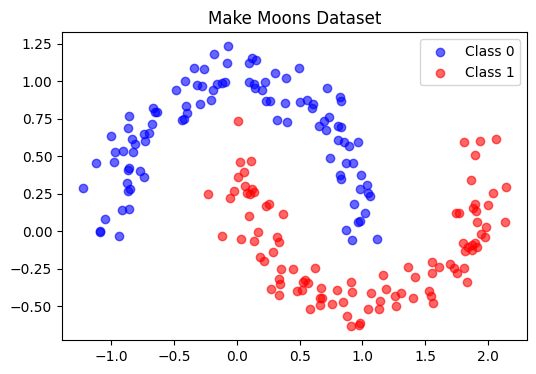

Dataset created successfully!
Training samples: 160, Test samples: 40


In [2]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Create dataset
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Visualize the dataset
plt.figure(figsize=(6,4))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], label="Class 0", color="blue", alpha=0.6)
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label="Class 1", color="red", alpha=0.6)
plt.title("Make Moons Dataset")
plt.legend()
plt.show()

print("Dataset created successfully!")
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Classical Neural Network Accuracy: 90.00%


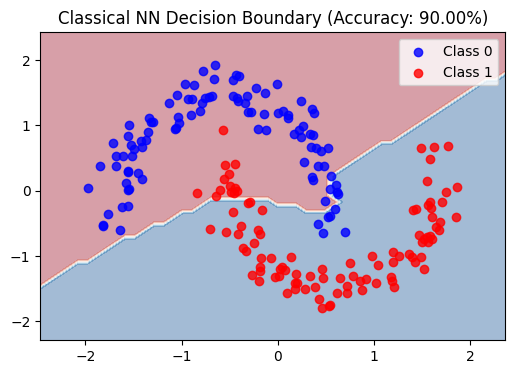

In [3]:
# Classical Neural Network
classical_model = MLPClassifier(
    hidden_layer_sizes=(8, 4),
    activation='relu',
    max_iter=1000,
    random_state=42
)

# Train it
classical_model.fit(X_train, y_train)

# Test it
classical_predictions = classical_model.predict(X_test)
classical_accuracy = accuracy_score(y_test, classical_predictions)

print(f"Classical Neural Network Accuracy: {classical_accuracy * 100:.2f}%")

# Visualize decision boundary
def plot_decision_boundary(model, X, y, title, is_quantum=False):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50))

    grid = np.c_[xx.ravel(), yy.ravel()]

    if is_quantum:
        Z = np.array([model(point) for point in grid])
    else:
        Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,4))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu')
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1],
                label="Class 0", color="blue", alpha=0.8)
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1],
                label="Class 1", color="red", alpha=0.8)
    plt.title(title)
    plt.legend()
    plt.show()

# Plot classical boundary
plot_decision_boundary(
    classical_model,
    X_scaled,
    y,
    f"Classical NN Decision Boundary (Accuracy: {classical_accuracy*100:.2f}%)"
)

In [4]:
# Define quantum device with 2 qubits
dev = qml.device("default.qubit", wires=2)

# Define the quantum circuit
@qml.qnode(dev)
def quantum_circuit(inputs, weights):
    # Encode classical data into quantum state
    qml.AngleEmbedding(inputs, wires=range(2))

    # Variational layers - this is where learning happens
    qml.BasicEntanglerLayers(weights, wires=range(2))

    # Measure the first qubit
    return qml.expval(qml.PauliZ(0))

# Quantum prediction function
def quantum_predict(X, weights):
    predictions = []
    for x in X:
        result = quantum_circuit(x, weights)
        # Convert from [-1,1] to [0,1]
        predictions.append(1 if result > 0 else 0)
    return np.array(predictions)

# Initialize random weights
np.random.seed(42)
num_layers = 3
weights = np.random.uniform(
    low=-np.pi,
    high=np.pi,
    size=(num_layers, 2),
    requires_grad=True
)

# Define cost function
def cost(weights, X, y):
    predictions = []
    for x in X:
        result = quantum_circuit(x, weights)
        predictions.append(result)
    predictions = np.array(predictions)
    # Convert labels from [0,1] to [-1,1]
    y_transformed = 2 * y - 1
    return np.mean((predictions - y_transformed) ** 2)

print("Quantum circuit defined successfully!")
print(f"Number of qubits: 2")
print(f"Number of variational layers: {num_layers}")
print(f"Total trainable parameters: {weights.size}")

# Draw the circuit
print("\nQuantum Circuit Architecture:")
drawer = qml.draw(quantum_circuit)
print(drawer(X_train[0], weights))

Quantum circuit defined successfully!
Number of qubits: 2
Number of variational layers: 3
Total trainable parameters: 6

Quantum Circuit Architecture:
0: ─╭AngleEmbedding(M0)─╭BasicEntanglerLayers(M1)─┤  <Z>
1: ─╰AngleEmbedding(M0)─╰BasicEntanglerLayers(M1)─┤     

M0 = 
[-0.45910932 -0.03433112]
M1 = 
[[-0.78828768  2.83192151]
 [ 1.45766093  0.61988954]
 [-2.16129862 -2.16145018]]


Training Quantum Neural Network...
----------------------------------------
Epoch 10/80 | Cost: 0.9162 | Test Accuracy: 70.00%
Epoch 20/80 | Cost: 0.9718 | Test Accuracy: 65.00%
Epoch 30/80 | Cost: 0.8192 | Test Accuracy: 67.50%
Epoch 40/80 | Cost: 0.6586 | Test Accuracy: 70.00%
Epoch 50/80 | Cost: 0.5843 | Test Accuracy: 70.00%
Epoch 60/80 | Cost: 0.7393 | Test Accuracy: 72.50%
Epoch 70/80 | Cost: 0.7202 | Test Accuracy: 72.50%
Epoch 80/80 | Cost: 0.8050 | Test Accuracy: 72.50%
----------------------------------------
Training Complete!


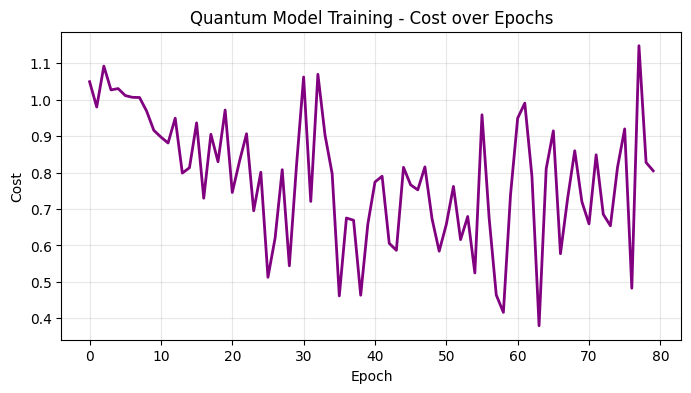

In [5]:
# Use gradient descent optimizer
optimizer = qml.GradientDescentOptimizer(stepsize=0.3)

# Training loop
epochs = 80
batch_size = 20
cost_history = []

print("Training Quantum Neural Network...")
print("-" * 40)

for epoch in range(epochs):
    # Use a random batch
    batch_idx = np.random.choice(len(X_train), batch_size, replace=False)
    X_batch = X_train[batch_idx]
    y_batch = y_train[batch_idx]

    # Update weights
    weights, current_cost = optimizer.step_and_cost(
        lambda w: cost(w, X_batch, y_batch),
        weights
    )

    cost_history.append(current_cost)

    if (epoch + 1) % 10 == 0:
        # Calculate accuracy on test set
        quantum_preds = quantum_predict(X_test, weights)
        acc = accuracy_score(y_test, quantum_preds)
        print(f"Epoch {epoch+1}/{epochs} | Cost: {current_cost:.4f} | Test Accuracy: {acc*100:.2f}%")

print("-" * 40)
print("Training Complete!")

# Plot training curve
plt.figure(figsize=(8,4))
plt.plot(cost_history, color='purple', linewidth=2)
plt.title("Quantum Model Training - Cost over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.grid(True, alpha=0.3)
plt.show()